<img src="https://webna.ir/wp-content/uploads/2018/08/%D9%85%DA%A9%D8%AA%D8%A8-%D8%AE%D9%88%D9%86%D9%87.png" width=50% />

<div class="alert alert-block alert-success">
    <h1 align="center">Machine Learning in Python</h1>
    <h3 align="center">Project2</h3>
</div>

<img src = "https://slitayem.github.io/img/blog/2020-08-04/churn.png" width=50%>

## Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,StandardScaler

## Load and Prepare Data

In [2]:
data = pd.read_csv("Churn.csv")

In [3]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
data.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


## EDA

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
pd.crosstab(data["Gender"],data["Exited"],normalize="index")

Exited,0,1
Gender,,
Female,0.749285,0.250715
Male,0.835441,0.164559


In [8]:
pd.crosstab(data["IsActiveMember"],data["Exited"],normalize="index")

Exited,0,1
IsActiveMember,,
0,0.731491,0.268509
1,0.857309,0.142691


In [9]:
pd.crosstab(data["HasCrCard"],data["Exited"],normalize="index")

Exited,0,1
HasCrCard,,
0,0.791851,0.208149
1,0.798157,0.201843


## Data Preprocessing

In [17]:
data.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [18]:
data.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [19]:
data.max()

RowNumber              10000
CustomerId          15815690
Surname               Zuyeva
CreditScore              850
Geography              Spain
Gender                  Male
Age                       92
Tenure                    10
Balance            250898.09
NumOfProducts              4
HasCrCard                  1
IsActiveMember             1
EstimatedSalary    199992.48
Exited                     1
dtype: object

In [20]:
data[['HasCrCard','IsActiveMember','Exited']] = data[['HasCrCard','IsActiveMember','Exited']].astype(bool)

In [21]:
data[['Age','Tenure','NumOfProducts']] = data[['Age','Tenure','NumOfProducts']].astype("int8")

In [22]:
data[['RowNumber','CreditScore']] = data[['RowNumber','CreditScore']].astype("int16")

In [23]:
data['CustomerId'] = data['CustomerId'].astype("int32")

In [24]:
data[['Balance','EstimatedSalary']] = data[['Balance','EstimatedSalary']].astype("float32")

In [25]:
data.dtypes

RowNumber            int16
CustomerId           int32
Surname             object
CreditScore          int16
Geography           object
Gender              object
Age                   int8
Tenure                int8
Balance            float32
NumOfProducts         int8
HasCrCard             bool
IsActiveMember        bool
EstimatedSalary    float32
Exited                bool
dtype: object

In [26]:
data["Gender"].replace({"Female" : 0 , "Male" : 1},inplace=True)
data["Gender"] = data["Gender"].astype(bool)

In [27]:
encoder = OneHotEncoder(handle_unknown="ignore",sparse_output=False).set_output(transform="pandas")

In [28]:
encoded = encoder.fit_transform(data[["Geography"]])

In [29]:
data = pd.concat([data,encoded.astype(bool)],axis=1)

## Strorytelling - Visualization

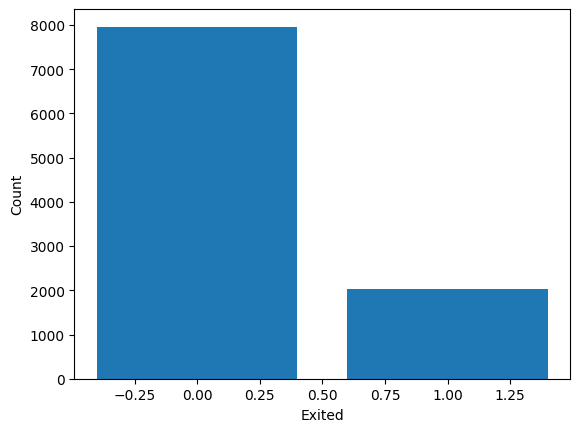

In [10]:
counts = data["Exited"].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()

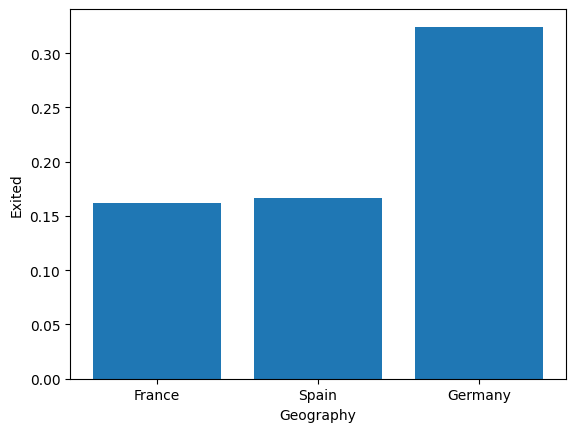

In [11]:
means = data.groupby("Geography")["Exited"].mean().sort_values()
plt.bar(means.index, means.values)
plt.xlabel("Geography")
plt.ylabel("Exited")
plt.show()

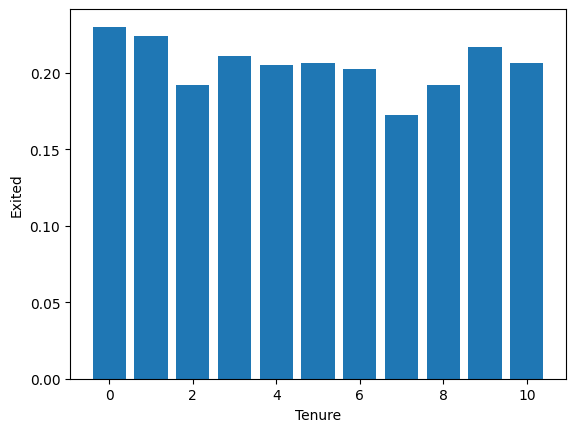

In [12]:
means = data.groupby("Tenure")["Exited"].mean().sort_values()
plt.bar(means.index, means.values)
plt.xlabel("Tenure")
plt.ylabel("Exited")
plt.show()

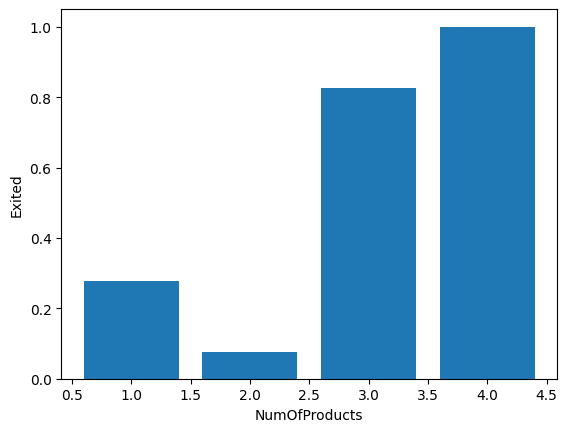

In [13]:
means = data.groupby("NumOfProducts")["Exited"].mean().sort_values()
plt.bar(means.index, means.values)
plt.xlabel("NumOfProducts")
plt.ylabel("Exited")
plt.show()

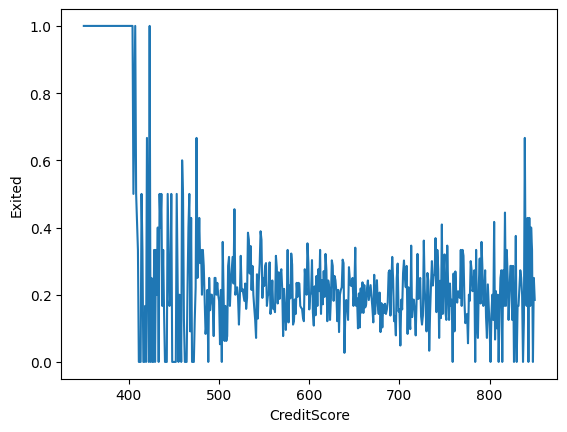

In [14]:
means = data.groupby("CreditScore")["Exited"].mean()
plt.plot(means.index, means.values)
plt.xlabel("CreditScore")
plt.ylabel("Exited")
plt.show()

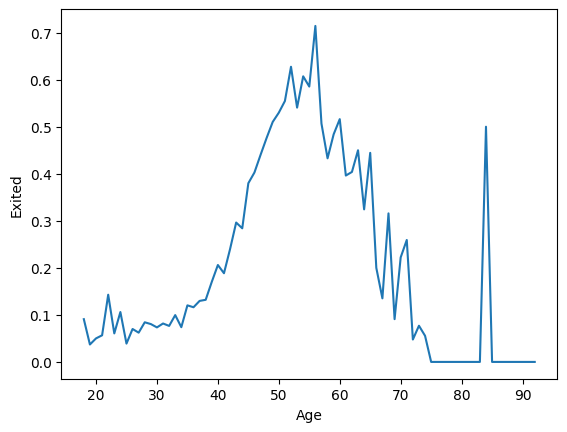

In [15]:
means = data.groupby("Age")["Exited"].mean()
plt.plot(means.index, means.values)
plt.xlabel("Age")
plt.ylabel("Exited")
plt.show()

In [32]:
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,France,False,42,2,0.000000,1,True,True,101348.882812,True,True,False,False
1,2,15647311,Hill,608,Spain,False,41,1,83807.859375,1,False,True,112542.578125,False,False,False,True
2,3,15619304,Onio,502,France,False,42,8,159660.796875,3,True,False,113931.570312,True,True,False,False
3,4,15701354,Boni,699,France,False,39,1,0.000000,2,False,False,93826.632812,False,True,False,False
4,5,15737888,Mitchell,850,Spain,False,43,2,125510.820312,1,True,True,79084.101562,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,True,39,5,0.000000,2,True,False,96270.640625,False,True,False,False
9996,9997,15569892,Johnstone,516,France,True,35,10,57369.609375,1,True,True,101699.773438,False,True,False,False
9997,9998,15584532,Liu,709,France,False,36,7,0.000000,1,False,True,42085.578125,True,True,False,False
9998,9999,15682355,Sabbatini,772,Germany,True,42,3,75075.312500,2,True,False,92888.523438,True,False,True,False


<Axes: >

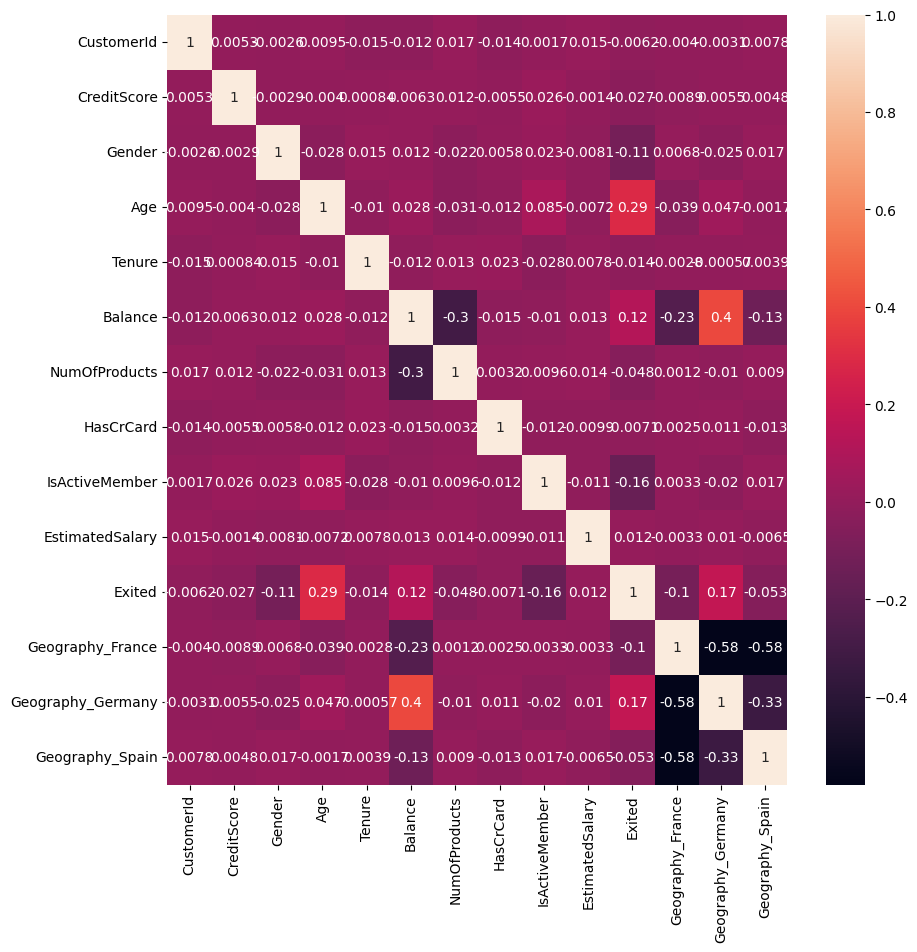

In [35]:
plt.figure(figsize=(10,10))
sns.heatmap(data.drop(["Surname","RowNumber","Geography"],axis=1).corr(),annot=True)

## Prepare Data for Machine learning

In [36]:
scaler = StandardScaler()
data[data.drop(columns=["Geography","Surname","Exited"]).columns] = scaler.fit_transform(data.drop(columns=["Geography","Surname","Exited"]))

## Train your model

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [38]:
X_train , X_test , Y_train , Y_test = train_test_split(data.drop(columns=["Geography","Surname","Exited"]),data["Exited"],test_size=.1,random_state=42)

In [39]:
rfc = RandomForestClassifier()

In [40]:
param={"criterion":["gini","entropy"],"class_weight":[None,{True:4,False:1},{True:3,False:1}]}

In [41]:
gsc = GridSearchCV(rfc,param_grid=param,scoring="f1",cv=5)

In [42]:
gsc.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'class_weight': [None, {False: 1, True: 4},
                                          {False: 1, True: 3}],
                         'criterion': ['gini', 'entropy']},
             scoring='f1')

In [43]:
gsc.best_score_

0.5743452597911617

In [44]:
gsc.best_params_

{'class_weight': None, 'criterion': 'gini'}

In [45]:
rfc = RandomForestClassifier(criterion='entropy').fit(X_train,Y_train)

In [46]:
rfc.score(X_train,Y_train)

1.0

In [53]:
from pycaret.classification import *

In [54]:
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,-1.731878,-0.783213,Hargrave,-0.326221,France,-1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021887,True,0.997204,-0.578736,-0.573809
1,-1.731531,-0.606534,Hill,-0.440036,Spain,-1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,False,-1.002804,-0.578736,1.742740
2,-1.731185,-0.995885,Onio,-1.536794,France,-1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,True,0.997204,-0.578736,-0.573809
3,-1.730838,0.144767,Boni,0.501521,France,-1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,False,0.997204,-0.578736,-0.573809
4,-1.730492,0.652659,Mitchell,2.063884,Spain,-1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,False,-1.002804,-0.578736,1.742740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.730492,-1.177652,Obijiaku,1.246488,France,0.912419,0.007457,-0.004426,-1.225848,0.807737,0.646092,-1.030670,-0.066419,False,0.997204,-0.578736,-0.573809
9996,1.730838,-1.682806,Johnstone,-1.391939,France,0.912419,-0.373958,1.724464,-0.306379,-0.911583,0.646092,0.970243,0.027988,False,0.997204,-0.578736,-0.573809
9997,1.731185,-1.479282,Liu,0.604988,France,-1.095988,-0.278604,0.687130,-1.225848,-0.911583,-1.547768,0.970243,-1.008643,True,0.997204,-0.578736,-0.573809
9998,1.731531,-0.119356,Sabbatini,1.256835,Germany,0.912419,0.293517,-0.695982,-0.022607,0.807737,0.646092,-1.030670,-0.125231,True,-1.002804,1.727904,-0.573809


In [56]:
cl = setup(data=data.drop(["Surname","Geography"],axis=1),target="Exited")

,Description,Value
0,Session id,3078
1,Target,Exited
2,Target type,Binary
3,Original data shape,"(10000, 15)"
4,Transformed data shape,"(10000, 15)"
5,Transformed train set shape,"(7000, 15)"
6,Transformed test set shape,"(3000, 15)"
7,Numeric features,14
8,Preprocess,True
9,Imputation type,simple


In [57]:
best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8664,0.8706,0.4895,0.7718,0.5980,0.5229,0.5429,0.3990
lightgbm,Light Gradient Boosting Machine,0.8641,0.8627,0.5127,0.7410,0.6049,0.5264,0.5400,0.1630
rf,Random Forest Classifier,0.8600,0.8557,0.4454,0.7718,0.5636,0.4875,0.5143,0.2630
et,Extra Trees Classifier,0.8554,0.8508,0.4159,0.7712,0.5389,0.4623,0.4941,0.1660
xgboost,Extreme Gradient Boosting,0.8553,0.8497,0.5042,0.7022,0.5863,0.5015,0.5120,0.1820
ada,Ada Boost Classifier,0.8533,0.8522,0.4839,0.7052,0.5727,0.4880,0.5013,0.1140
knn,K Neighbors Classifier,0.8213,0.7650,0.3394,0.6128,0.4362,0.3402,0.3616,0.0830
nb,Naive Bayes,0.8179,0.7839,0.3703,0.5870,0.4529,0.3504,0.3644,0.0150
lr,Logistic Regression,0.8097,0.7649,0.2146,0.5949,0.3142,0.2312,0.2725,0.7360
lda,Linear Discriminant Analysis,0.8091,0.7678,0.2385,0.5804,0.3367,0.2475,0.2816,0.0160


C:\Users\sajad\pycaret\Lib\site-packages\pycaret\internal\pycaret_experiment\supervised_experiment.py:339: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_cols, subset=["TT (Sec)"])


## Test the model and show the metrics

In [47]:
print(classification_report(Y_test,rfc.predict(X_test)))

              precision    recall  f1-score   support

       False       0.88      0.97      0.92       809
        True       0.75      0.45      0.56       191

    accuracy                           0.87      1000
   macro avg       0.82      0.71      0.74      1000
weighted avg       0.86      0.87      0.85      1000



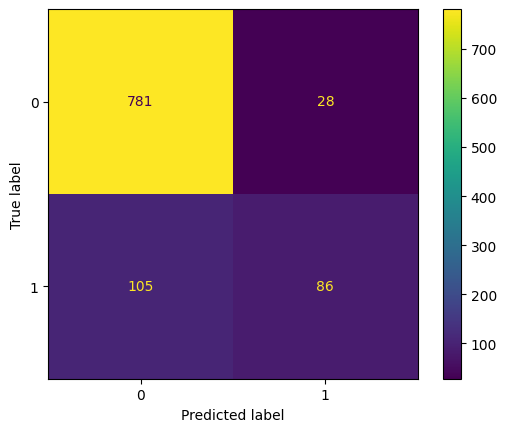

In [48]:
ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(Y_test,rfc.predict(X_test)), display_labels = [0, 1]).plot()

## Save your final model

In [49]:
from pycaret.classification import save_model

In [58]:
save_model(rfc, 'my_best_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['RowNumber', 'CustomerId',
                                              'CreditScore', 'Gender', 'Age',
                                              'Tenure', 'Balance',
                                              'NumOfProducts', 'HasCrCard',
                                              'IsActiveMember',
                                              'EstimatedSalary',
                                              'Geography_France',
                                              'Geography_Germany',
                                              'Geography_Spain'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               cop...
                  RandomForestClassifier(bootstrap=True, ccp_alpha=0.0,
                      

## Send us the Result (Maktabkhoone)